In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing.pipeline import preprocess_text

sample = "My account is not working after the update."

print(preprocess_text(sample))

account working update


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
df = pd.read_csv("../data/processed/customer_support_en.csv")

print(df.shape)

df.head()

(16338, 17)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text_length
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,544
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,534
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,605
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,677
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN,646


In [4]:
df["combined_text"] = (
    df["subject"].fillna("")
    + " "
    + df["body"].fillna("")
)

df = df[["combined_text", "type"]]

df.head()

,combined_text,type
0,"Account Disruption Dear Customer Support Team,...",Incident
1,Query About Smart Home System Integration Feat...,Request
2,Inquiry Regarding Invoice Details Dear Custome...,Request
3,Question About Marketing Agency Software Compa...,Problem
4,"Feature Query Dear Customer Support,\n\nI hope...",Request


In [5]:
import sys
sys.path.append("..")

from src.preprocessing.pipeline import preprocess_text

In [6]:
df["processed_text"] = df["combined_text"].apply(preprocess_text)

df[["combined_text","processed_text"]].head()

,combined_text,processed_text
0,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support team ...
1,Query About Smart Home System Integration Feat...,query smart home system integration feature de...
2,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice detail dear customer...
3,Question About Marketing Agency Software Compa...,question marketing agency software compatibili...
4,"Feature Query Dear Customer Support,\n\nI hope...",feature query dear customer support n ni hope ...


In [7]:
X = df["processed_text"]

y = df["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(13070,)
(3268,)


In [8]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(13070, 4182)


In [9]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [10]:
predictions = model.predict(
    X_test_tfidf
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.8369033047735618


In [11]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

      Change       0.99      0.96      0.98       341
    Incident       0.76      0.89      0.82      1314
     Problem       0.67      0.46      0.55       680
     Request       0.99      1.00      0.99       933

    accuracy                           0.84      3268
   macro avg       0.85      0.83      0.83      3268
weighted avg       0.83      0.84      0.83      3268



In [12]:
confusion_matrix(
    y_test,
    predictions
)

array([[ 327,    4,    0,   10],
       [   1, 1163,  150,    0],
       [   1,  363,  313,    3],
       [   0,    0,    1,  932]])

In [14]:
import os

print(os.getcwd())

print(os.path.exists("../src/models/member1"))

c:\Users\USER\Desktop\NLP Project\NLP_Group_35\notebooks
False


In [15]:
import os

os.makedirs("../src/models/member1", exist_ok=True)

In [16]:
joblib.dump(
    model,
    "../src/models/member1/logistic_regression.pkl"
)

print("Model Saved")

Model Saved


In [17]:
print("Accuracy:", accuracy)

Accuracy: 0.8369033047735618


In [18]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      Change       0.99      0.96      0.98       341
    Incident       0.76      0.89      0.82      1314
     Problem       0.67      0.46      0.55       680
     Request       0.99      1.00      0.99       933

    accuracy                           0.84      3268
   macro avg       0.85      0.83      0.83      3268
weighted avg       0.83      0.84      0.83      3268



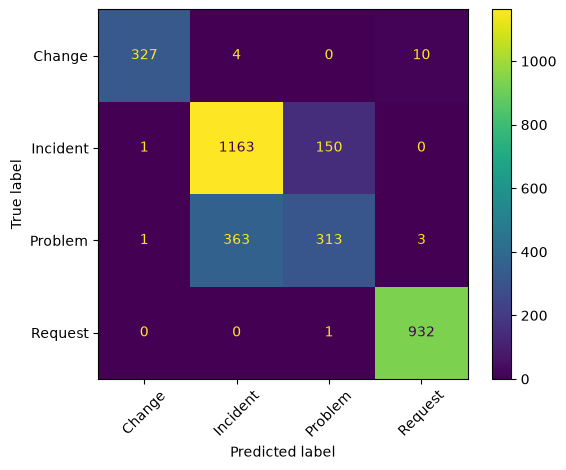

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    xticks_rotation=45
)

plt.show()